<a href="https://colab.research.google.com/github/Trang19/6680/blob/main/power_resilience_2014_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import glob
print("Searching your Google Drive for your dataset folders...\n")
drive_base = "/content/drive/MyDrive"
folder_51 = None
folder_13 = None
# Scan Google Drive directories
for root, dirs, files in os.walk(drive_base):
    # Count CSV and CSV.GZ files
    csv_files = [f for f in files if f.endswith('.csv') or f.endswith('.csv.gz')]
    count = len(csv_files)

    if count == 51:
        folder_51 = root
        print(f"🎯 FOUND FOLDER 1 (51 files): {root}")
    elif count == 13:
        folder_13 = root
        print(f"🎯 FOUND FOLDER 2 (13 files): {root}")
    elif count > 0:
        # Show other candidate folders if exact numbers differ slightly
        print(f"📁 Other folder with CSVs: {root} ({count} files)")
print("\n------------------------------------------------")
if folder_51 and folder_13:
    print("SUCCESS! Both folders automatically found and linked:")
    print(f"  Folder 51: {folder_51}")
    print(f"  Folder 13: {folder_13}")
else:
    print("If the exact numbers aren't 51 and 13, look at the folder list above to find your folder names.")

Searching your Google Drive for your dataset folders...

📁 Other folder with CSVs: /content/drive/MyDrive/power_resilience_2014_2023/Outage_Dataset (50 files)
🎯 FOUND FOLDER 2 (13 files): /content/drive/MyDrive/power_resilience_2014_2023/StormEvents

------------------------------------------------
If the exact numbers aren't 51 and 13, look at the folder list above to find your folder names.


In [3]:
import os
import glob
import pandas as pd
outage_folder = "/content/drive/MyDrive/power_resilience_2014_2023/Outage_Dataset"
storm_folder = "/content/drive/MyDrive/power_resilience_2014_2023/StormEvents"
outage_files = sorted(glob.glob(os.path.join(outage_folder, "*.csv*")))
storm_files = sorted(glob.glob(os.path.join(storm_folder, "*.csv*")))
print(f"Total Outage State Files: {len(outage_files)}")
print(f"Total Storm Years Files:  {len(storm_files)}")
# Peek at the columns of the first outage file
sample_outage = pd.read_csv(outage_files[0], nrows=2)
print("\n--- Columns in Outage Dataset ---")
print(sample_outage.columns.tolist())
display(sample_outage.head(1))
# Peek at the columns of the first storm file
sample_storm = pd.read_csv(storm_files[0], nrows=2)
print("\n--- Columns in StormEvents Dataset ---")
print(sample_storm.columns.tolist())
display(sample_storm.head(1))

Total Outage State Files: 50
Total Storm Years Files:  13

--- Columns in Outage Dataset ---
['state', 'year', 'month', 'outage_count', 'max_outage_duration', 'customer_weighted_hours']


,state,year,month,outage_count,max_outage_duration,customer_weighted_hours
0,Alabama,2014,0,33,26.5,51208.25



--- Columns in StormEvents Dataset ---
['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH', 'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS', 'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME', 'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME', 'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE', 'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE', 'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE', 'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 'BEGIN_RANGE', 'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH', 'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON', 'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE']


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,201402,18,1000,201402,18,2000,83473,503953,NEW HAMPSHIRE,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low pressure developing south of Long Island a...,Eight to twelve inches of snow fell across eas...,CSV


In [4]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
print("--- 1. Loading All 50 State Outage Files ---")
outage_dfs = []
for f in outage_files:
    df_temp = pd.read_csv(f)
    df_temp.columns = df_temp.columns.str.strip().str.lower()
    outage_dfs.append(df_temp)
outage_master = pd.concat(outage_dfs, ignore_index=True)
# Standardize State name and Month (1 to 12)
outage_master['state_clean'] = outage_master['state'].astype(str).str.strip().str.upper()
# If month is 0-indexed (0 to 11), shift to 1-12
if outage_master['month'].min() == 0 and outage_master['month'].max() <= 11:
    outage_master['month_num'] = outage_master['month'] + 1
else:
    outage_master['month_num'] = outage_master['month']
print(f"Loaded Outage Data: {len(outage_master):,} state-month records across {outage_master['state_clean'].nunique()} states.")
# --------------------------------------------------------
print("\n--- 2. Loading All 13 NOAA Storm Events Years ---")
storm_cols = ['STATE', 'YEAR', 'BEGIN_YEARMONTH', 'EVENT_TYPE', 'MAGNITUDE']
storm_dfs = []
for f in storm_files:
    df_temp = pd.read_csv(f, usecols=lambda c: c.strip() in storm_cols, low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()
    storm_dfs.append(df_temp)
storm_master = pd.concat(storm_dfs, ignore_index=True)
storm_master['state_clean'] = storm_master['STATE'].astype(str).str.strip().str.upper()
storm_master['month_num'] = storm_master['BEGIN_YEARMONTH'] % 100
storm_master['year'] = storm_master['YEAR']
print(f"Loaded NOAA Data: {len(storm_master):,} individual storm hazard records.")
# --------------------------------------------------------
print("\n--- 3. Aggregating Storms to State-Year-Month Level ---")
# For each state-year-month, calculate total storm events, dominant hazard, and max wind
def get_dominant_hazard(series):
    mode_val = series.mode()
    return mode_val.iloc[0] if not mode_val.empty else "Severe Weather"
storm_monthly = storm_master.groupby(['state_clean', 'year', 'month_num']).agg(
    storm_count=('EVENT_TYPE', 'count'),
    dominant_hazard=('EVENT_TYPE', get_dominant_hazard),
    max_magnitude=('MAGNITUDE', 'max')
).reset_index()
storm_monthly['max_magnitude'] = storm_monthly['max_magnitude'].fillna(0)
# --------------------------------------------------------
print("\n--- 4. Merging Outages with Storm Events ---")
df_master = pd.merge(
    outage_master,
    storm_monthly,
    on=['state_clean', 'year', 'month_num'],
    how='inner'
)
# Feature engineering: Add season
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall', 11: 'Fall'}
df_master['season'] = df_master['month_num'].map(season_map)
# Filter out non-positive durations for statistical reliability modeling
analysis_df = df_master[df_master['max_outage_duration'] > 0].copy()
print(f"\n=======================================================")
print(f"SUCCESS: Master 10-Year Dataset Built: {len(analysis_df):,} matched state-months!")
print(f"=======================================================")
display(analysis_df[['state_clean', 'year', 'month_num', 'dominant_hazard', 'outage_count', 'max_outage_duration', 'customer_weighted_hours']].head(10))

--- 1. Loading All 50 State Outage Files ---
Loaded Outage Data: 2,124,183 state-month records across 54 states.

--- 2. Loading All 13 NOAA Storm Events Years ---
Loaded NOAA Data: 810,364 individual storm hazard records.

--- 3. Aggregating Storms to State-Year-Month Level ---

--- 4. Merging Outages with Storm Events ---

SUCCESS: Master 10-Year Dataset Built: 5,429 matched state-months!


,state_clean,year,month_num,dominant_hazard,outage_count,max_outage_duration,customer_weighted_hours
10,ALABAMA,2014.0,11.0,Frost/Freeze,18.0,26.50,42203.75
11,ALABAMA,2014.0,12.0,Thunderstorm Wind,15.0,2.50,9004.50
22,ARKANSAS,2014.0,11.0,Winter Weather,79.0,8.50,103117.25
23,ARKANSAS,2014.0,12.0,Thunderstorm Wind,74.0,7.00,141920.50
34,CALIFORNIA,2014.0,11.0,High Wind,415.0,59.25,2607854.25
35,CALIFORNIA,2014.0,12.0,Flood,430.0,139.50,3499853.75
46,COLORADO,2014.0,11.0,Winter Weather,136.0,8.25,243791.25
47,COLORADO,2014.0,12.0,Winter Weather,34.0,4.00,28958.75
58,CONNECTICUT,2014.0,11.0,Strong Wind,108.0,31.50,222859.00
59,CONNECTICUT,2014.0,12.0,Strong Wind,78.0,6.25,74326.00


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.7 MB/s eta 0:00:00


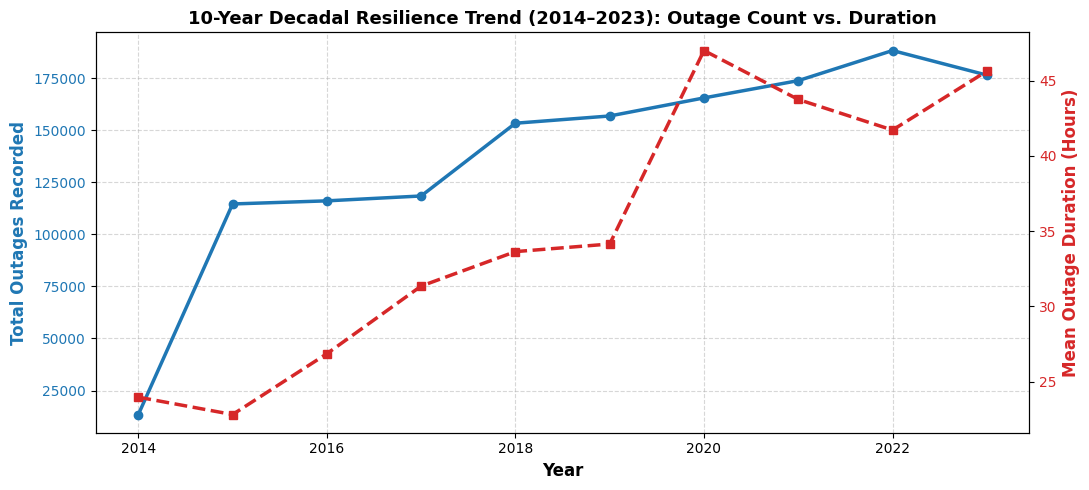

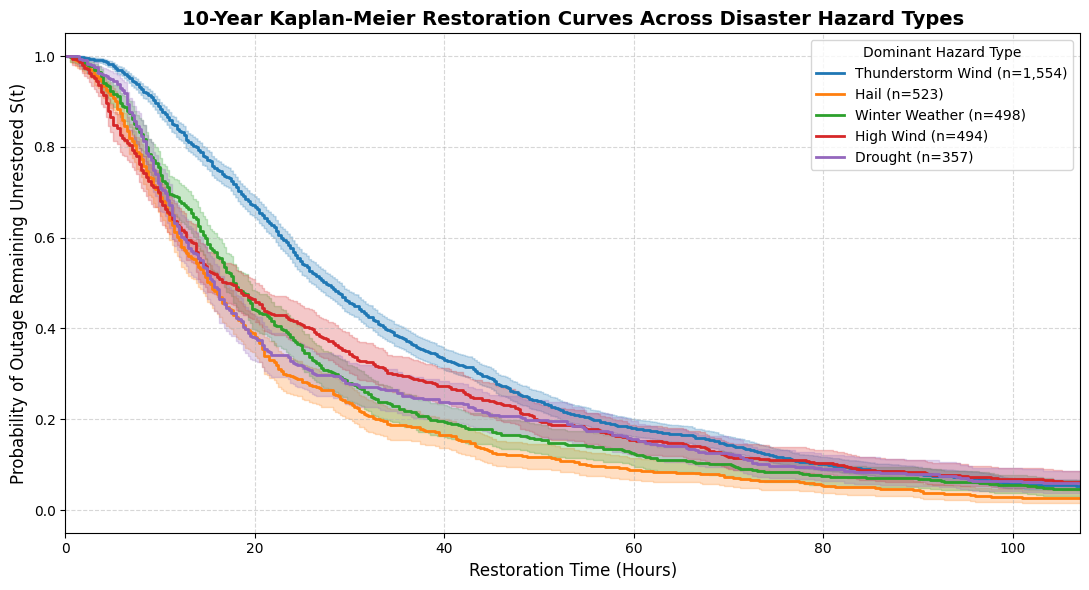


--- Weibull Reliability Modeling Parameters ---


,Hazard Type,Sample Size,MTTR (Mean Hrs),Median Duration (Hrs),Weibull Shape (β),Weibull Scale (η)
0,Thunderstorm Wind,1554,40.67,27.50,1.140,42.95
4,Drought,357,35.45,15.75,0.864,32.04
3,High Wind,494,33.03,17.25,0.935,31.88
2,Winter Weather,498,30.23,17.88,1.008,30.35
1,Hail,523,24.79,15.25,1.049,25.36



--- TOP 10 STATES WITH SLOWEST RECOVERY (Highest CIP Hardening Priority) ---


,state_clean,total_outages,mean_duration_hrs,total_customer_hours,worst_single_outage
0,CALIFORNIA,98104.0,131.227273,6.704362e+08,609.75
1,PUERTO RICO,13539.0,87.166667,3.818387e+08,409.25
2,TEXAS,121417.0,76.334091,6.194800e+08,723.75
3,LOUISIANA,49267.0,75.404545,5.183902e+08,1035.75
4,MICHIGAN,48305.0,61.106818,5.106057e+08,370.25
5,FLORIDA,106200.0,56.138636,1.015741e+09,532.75
6,OREGON,11740.0,52.165909,9.837357e+07,563.00
7,TENNESSEE,31445.0,49.561364,1.355295e+08,305.00
8,SOUTH CAROLINA,23936.0,48.939815,1.140775e+08,369.75
9,NEW YORK,56151.0,47.827273,2.736783e+08,240.50


/tmp/ipykernel_1067/139242479.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_cip_ranking.head(10), x='mean_duration_hrs', y='state_clean', palette='Reds_r')


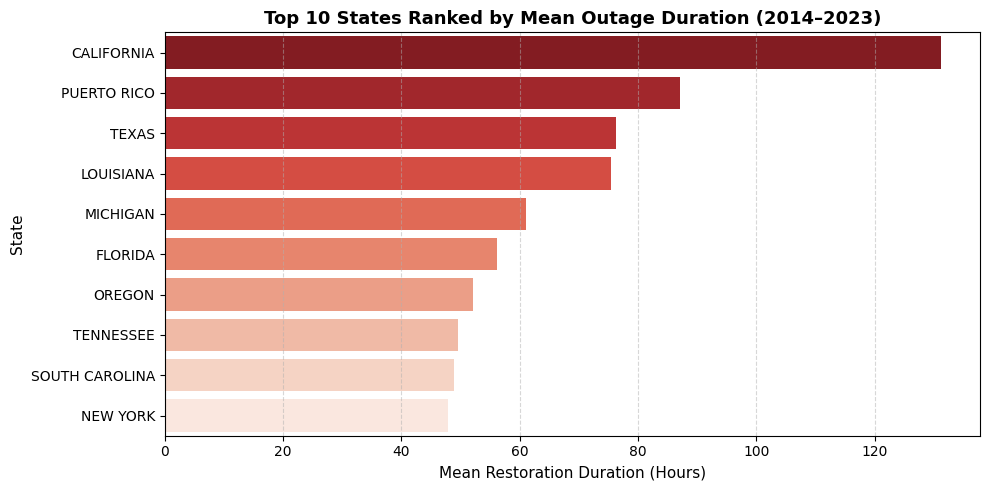

In [5]:
!pip install lifelines -q
from lifelines import KaplanMeierFitter, WeibullFitter
import statsmodels.api as sm
# --------------------------------------------------------
# 1. 10-YEAR DECADAL TREND ANALYSIS (2014–2023)
# --------------------------------------------------------
annual_trend = analysis_df.groupby('year').agg(
    total_outages=('outage_count', 'sum'),
    mean_duration=('max_outage_duration', 'mean'),
    total_cust_hours=('customer_weighted_hours', 'sum')
).reset_index()
fig, ax1 = plt.subplots(figsize=(11, 5))
color = 'tab:blue'
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Outages Recorded', color=color, fontsize=12, fontweight='bold')
ax1.plot(annual_trend['year'], annual_trend['total_outages'], color=color, marker='o', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Mean Outage Duration (Hours)', color=color, fontsize=12, fontweight='bold')
ax2.plot(annual_trend['year'], annual_trend['mean_duration'], color=color, marker='s', linewidth=2.5, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)
plt.title("10-Year Decadal Resilience Trend (2014–2023): Outage Count vs. Duration", fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()
# --------------------------------------------------------
# 2. KAPLAN-MEIER SURVIVAL ANALYSIS BY TOP HAZARDS
# --------------------------------------------------------
top_hazards = analysis_df['dominant_hazard'].value_counts().nlargest(5).index.tolist()
km_data = analysis_df[analysis_df['dominant_hazard'].isin(top_hazards)].copy()
km_data['event_observed'] = 1
plt.figure(figsize=(11, 6))
kmf = KaplanMeierFitter()
colors = sns.color_palette("tab10", len(top_hazards))
for i, hazard in enumerate(top_hazards):
    mask = km_data['dominant_hazard'] == hazard
    durations = km_data.loc[mask, 'max_outage_duration']
    kmf.fit(durations, event_observed=km_data.loc[mask, 'event_observed'], label=f"{hazard} (n={len(durations):,})")
    kmf.plot_survival_function(ci_show=True, color=colors[i], linewidth=2)
plt.title("10-Year Kaplan-Meier Restoration Curves Across Disaster Hazard Types", fontsize=14, fontweight='bold')
plt.xlabel("Restoration Time (Hours)", fontsize=12)
plt.ylabel("Probability of Outage Remaining Unrestored S(t)", fontsize=12)
plt.xlim(0, km_data['max_outage_duration'].quantile(0.95))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Dominant Hazard Type")
plt.tight_layout()
plt.show()
# --------------------------------------------------------
# 3. WEIBULL RELIABILITY PARAMETERS (MTTR & SHAPE β)
# --------------------------------------------------------
weibull_records = []
for hazard in top_hazards:
    durations = km_data[km_data['dominant_hazard'] == hazard]['max_outage_duration']
    wf = WeibullFitter()
    wf.fit(durations)
    weibull_records.append({
        'Hazard Type': hazard,
        'Sample Size': len(durations),
        'MTTR (Mean Hrs)': round(durations.mean(), 2),
        'Median Duration (Hrs)': round(durations.median(), 2),
        'Weibull Shape (β)': round(wf.rho_, 3),
        'Weibull Scale (η)': round(wf.lambda_, 2)
    })
weibull_df = pd.DataFrame(weibull_records).sort_values(by='MTTR (Mean Hrs)', ascending=False)
print("\n--- Weibull Reliability Modeling Parameters ---")
display(weibull_df)
# --------------------------------------------------------
# 4. 50-STATE CIP RESILIENCE RANKING (Objective 3)
# --------------------------------------------------------
state_cip_ranking = analysis_df.groupby('state_clean').agg(
    total_outages=('outage_count', 'sum'),
    mean_duration_hrs=('max_outage_duration', 'mean'),
    total_customer_hours=('customer_weighted_hours', 'sum'),
    worst_single_outage=('max_outage_duration', 'max')
).reset_index().sort_values(by='mean_duration_hrs', ascending=False).reset_index(drop=True)
print("\n--- TOP 10 STATES WITH SLOWEST RECOVERY (Highest CIP Hardening Priority) ---")
display(state_cip_ranking.head(10))
plt.figure(figsize=(10, 5))
sns.barplot(data=state_cip_ranking.head(10), x='mean_duration_hrs', y='state_clean', palette='Reds_r')
plt.title("Top 10 States Ranked by Mean Outage Duration (2014–2023)", fontsize=13, fontweight='bold')
plt.xlabel("Mean Restoration Duration (Hours)", fontsize=11)
plt.ylabel("State", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [6]:
import os
import zipfile
from google.colab import files
export_dir = "/content/final_deliverables"
os.makedirs(export_dir, exist_ok=True)
# 1. Export summary tables
weibull_df.to_csv(os.path.join(export_dir, "table1_weibull_hazard_reliability.csv"), index=False)
state_cip_ranking.to_csv(os.path.join(export_dir, "table2_50state_cip_rankings.csv"), index=False)
annual_trend.to_csv(os.path.join(export_dir, "table3_10year_decadal_trend.csv"), index=False)
# 2. Package everything into a ZIP
zip_name = "/content/INSE6680_Project_Deliverables.zip"
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for root, _, files_list in os.walk(export_dir):
        for f in files_list:
            zipf.write(os.path.join(root, f), arcname=f)
print("Export completed! Downloading ZIP archive to your computer now...")
files.download(zip_name)

Export completed! Downloading ZIP archive to your computer now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_1067/1835865044.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1067/1835865044.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1067/1835865044.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


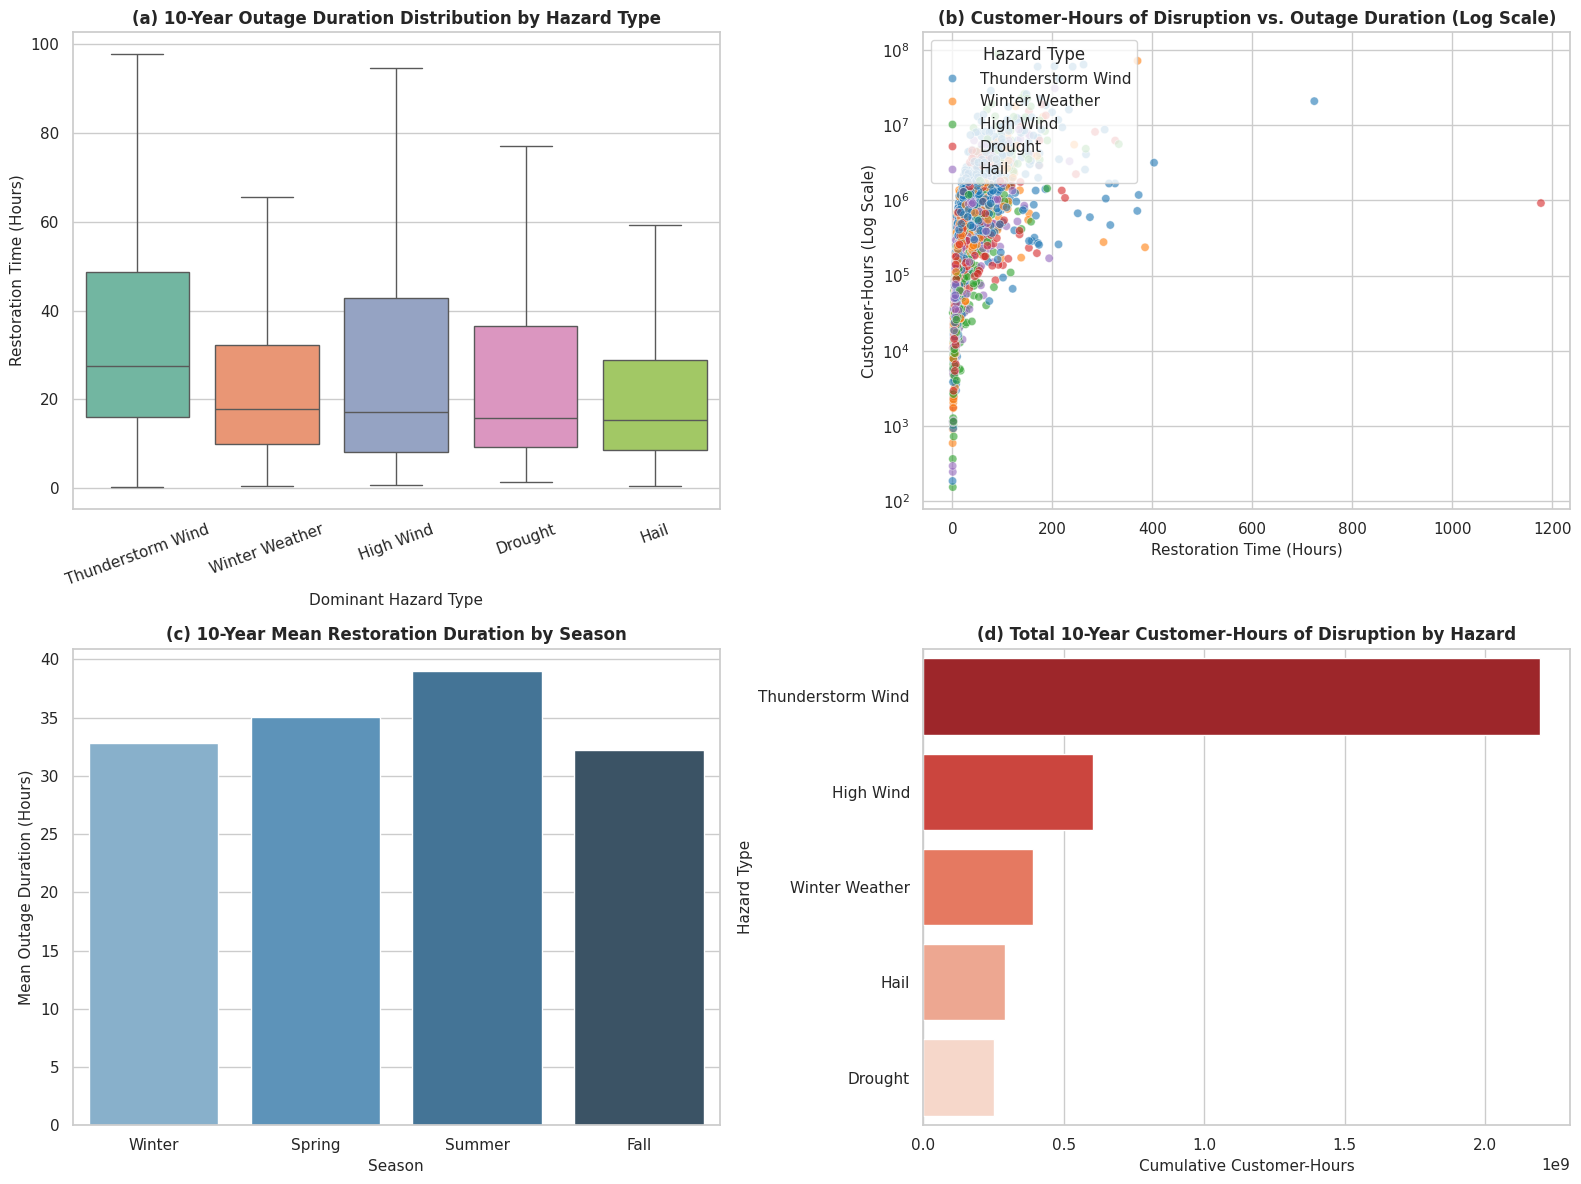

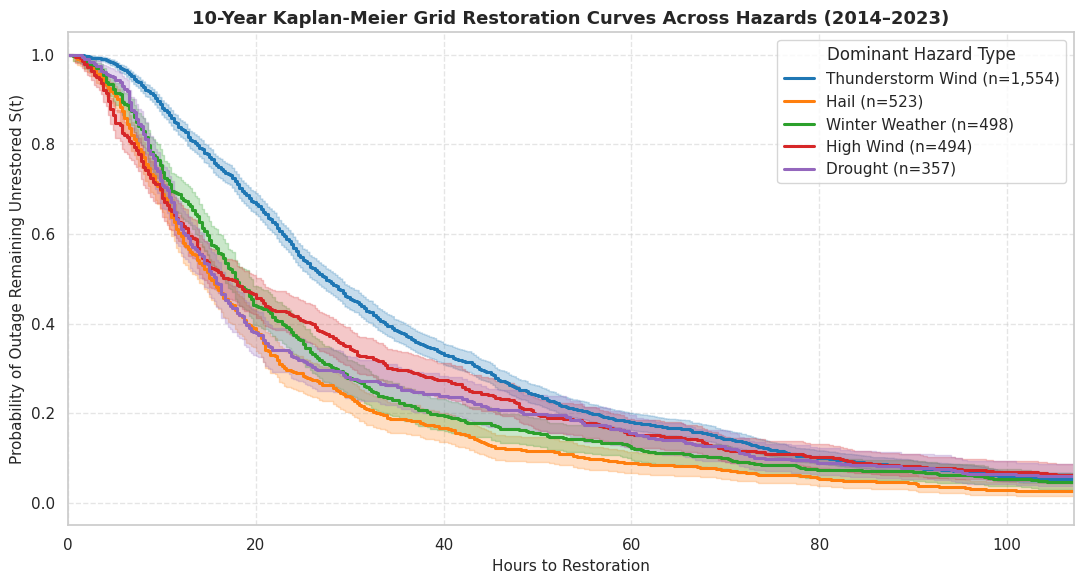

/tmp/ipykernel_1067/1835865044.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_mttr, x='mean_duration', y='state_clean', palette='Reds_r')


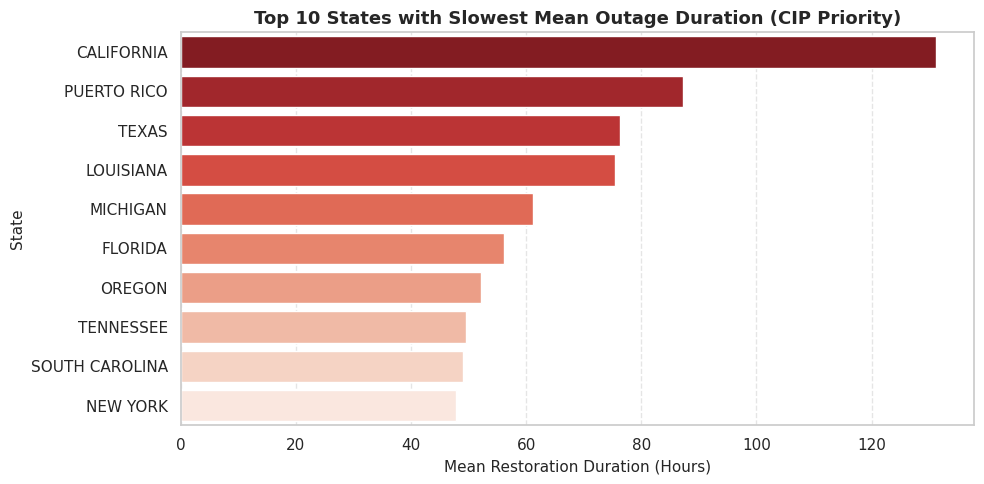

/tmp/ipykernel_1067/1835865044.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_cust, x='total_cust_hours', y='state_clean', palette='Blues_r')


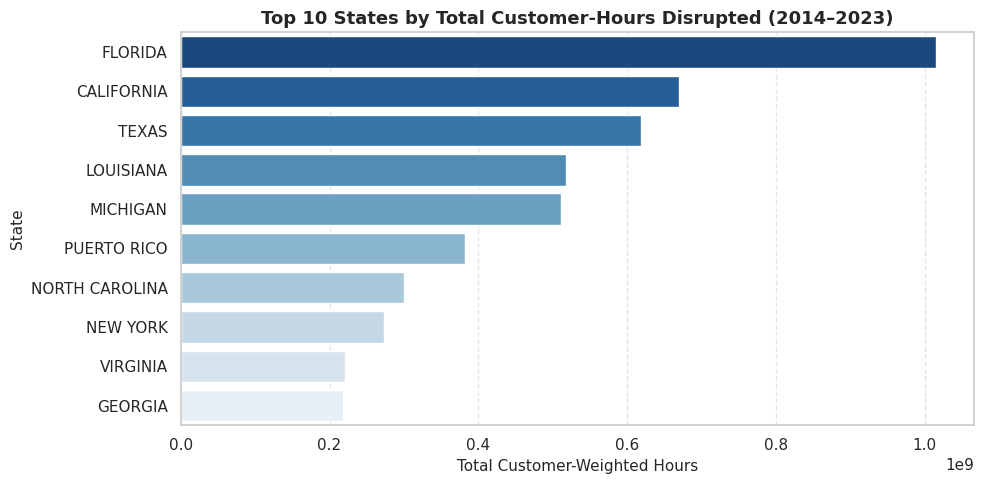

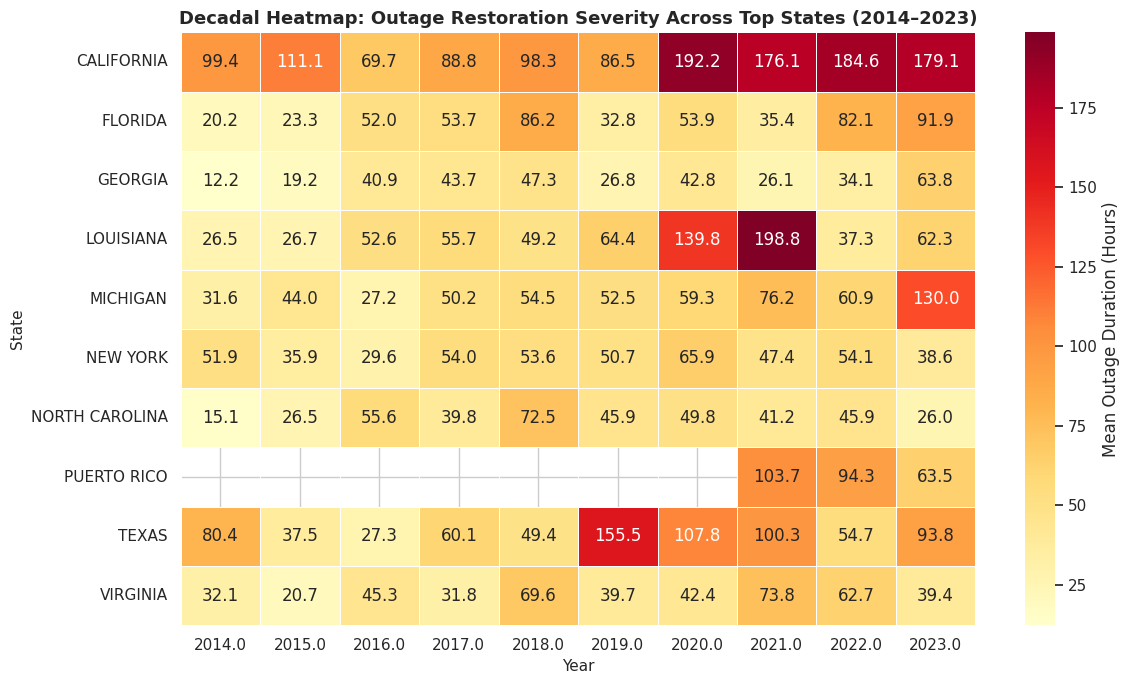


ALL 5 HIGH-RESOLUTION PUBLICATION FIGURES SAVED TO:
/content/final_deliverables/figures


In [7]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
# Create export folder for high-res images
fig_dir = "/content/final_deliverables/figures"
os.makedirs(fig_dir, exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.0)
top_hazards = analysis_df['dominant_hazard'].value_counts().nlargest(5).index.tolist()
plot_df = analysis_df[analysis_df['dominant_hazard'].isin(top_hazards)].copy()
# ========================================================
# FIGURE 1: 4-PANEL PUBLICATION SUMMARY (IEEE FORMAT)
# ========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 1A: Outage Duration Distribution by Hazard Type
sns.boxplot(
    data=plot_df,
    x='dominant_hazard',
    y='max_outage_duration',
    palette='Set2',
    ax=axes[0, 0],
    showfliers=False
)
axes[0, 0].set_title("(a) 10-Year Outage Duration Distribution by Hazard Type", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Dominant Hazard Type", fontsize=11)
axes[0, 0].set_ylabel("Restoration Time (Hours)", fontsize=11)
axes[0, 0].tick_params(axis='x', rotation=20)
# 1B: Customer-Hours vs Duration (Log Scale)
sns.scatterplot(
    data=plot_df,
    x='max_outage_duration',
    y='customer_weighted_hours',
    hue='dominant_hazard',
    alpha=0.6,
    palette='tab10',
    ax=axes[0, 1]
)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title("(b) Customer-Hours of Disruption vs. Outage Duration (Log Scale)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Restoration Time (Hours)", fontsize=11)
axes[0, 1].set_ylabel("Customer-Hours (Log Scale)", fontsize=11)
axes[0, 1].legend(title="Hazard Type", loc="upper left")
# 1C: Seasonal Resilience (Winter, Spring, Summer, Fall)
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
sns.barplot(
    data=plot_df,
    x='season',
    y='max_outage_duration',
    order=season_order,
    palette='Blues_d',
    errorbar=None,
    ax=axes[1, 0]
)
axes[1, 0].set_title("(c) 10-Year Mean Restoration Duration by Season", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Season", fontsize=11)
axes[1, 0].set_ylabel("Mean Outage Duration (Hours)", fontsize=11)
# 1D: Total Customer-Hours Disrupted by Hazard Type
hazard_impact = plot_df.groupby('dominant_hazard')['customer_weighted_hours'].sum().reset_index()
sns.barplot(
    data=hazard_impact.sort_values(by='customer_weighted_hours', ascending=False),
    x='customer_weighted_hours',
    y='dominant_hazard',
    palette='Reds_r',
    ax=axes[1, 1]
)
axes[1, 1].set_title("(d) Total 10-Year Customer-Hours of Disruption by Hazard", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Cumulative Customer-Hours", fontsize=11)
axes[1, 1].set_ylabel("Hazard Type", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig1_4panel_resilience_overview.png"), dpi=300, bbox_inches='tight')
plt.show()
# ========================================================
# FIGURE 2: 10-YEAR KAPLAN-MEIER SURVIVAL CURVES
# ========================================================
plt.figure(figsize=(11, 6))
kmf = KaplanMeierFitter()
colors = sns.color_palette("tab10", len(top_hazards))
plot_df['event_observed'] = 1
for i, hazard in enumerate(top_hazards):
    mask = plot_df['dominant_hazard'] == hazard
    durations = plot_df.loc[mask, 'max_outage_duration']
    kmf.fit(durations, event_observed=plot_df.loc[mask, 'event_observed'], label=f"{hazard} (n={len(durations):,})")
    kmf.plot_survival_function(ci_show=True, color=colors[i], linewidth=2.2)
plt.title("10-Year Kaplan-Meier Grid Restoration Curves Across Hazards (2014–2023)", fontsize=13, fontweight='bold')
plt.xlabel("Hours to Restoration", fontsize=11)
plt.ylabel("Probability of Outage Remaining Unrestored S(t)", fontsize=11)
plt.xlim(0, plot_df['max_outage_duration'].quantile(0.95))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Dominant Hazard Type", loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig2_kaplan_meier_curves.png"), dpi=300, bbox_inches='tight')
plt.show()
# ========================================================
# FIGURE 3: TOP 10 STATES BY MTTR (VULNERABILITY RANKING)
# ========================================================
state_stats = analysis_df.groupby('state_clean').agg(
    mean_duration=('max_outage_duration', 'mean'),
    total_cust_hours=('customer_weighted_hours', 'sum'),
    total_outages=('outage_count', 'sum')
).reset_index()
plt.figure(figsize=(10, 5))
top10_mttr = state_stats.sort_values(by='mean_duration', ascending=False).head(10)
sns.barplot(data=top10_mttr, x='mean_duration', y='state_clean', palette='Reds_r')
plt.title("Top 10 States with Slowest Mean Outage Duration (CIP Priority)", fontsize=13, fontweight='bold')
plt.xlabel("Mean Restoration Duration (Hours)", fontsize=11)
plt.ylabel("State", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig3_top10_states_mttr.png"), dpi=300, bbox_inches='tight')
plt.show()
# ========================================================
# FIGURE 4: TOP 10 STATES BY TOTAL CUSTOMER-HOURS DISRUPTED
# ========================================================
plt.figure(figsize=(10, 5))
top10_cust = state_stats.sort_values(by='total_cust_hours', ascending=False).head(10)
sns.barplot(data=top10_cust, x='total_cust_hours', y='state_clean', palette='Blues_r')
plt.title("Top 10 States by Total Customer-Hours Disrupted (2014–2023)", fontsize=13, fontweight='bold')
plt.xlabel("Total Customer-Weighted Hours", fontsize=11)
plt.ylabel("State", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig4_top10_states_customer_hours.png"), dpi=300, bbox_inches='tight')
plt.show()
# ========================================================
# FIGURE 5: 10-YEAR HEATMAP (ANNUAL DISASTER SEVERITY BY STATE)
# ========================================================
# Pick Top 15 most impacted states
top15_states = top10_cust['state_clean'].head(15).tolist()
heatmap_data = analysis_df[analysis_df['state_clean'].isin(top15_states)].pivot_table(
    index='state_clean',
    columns='year',
    values='max_outage_duration',
    aggfunc='mean'
)
plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt=".1f", linewidths=.5, cbar_kws={'label': 'Mean Outage Duration (Hours)'})
plt.title("Decadal Heatmap: Outage Restoration Severity Across Top States (2014–2023)", fontsize=13, fontweight='bold')
plt.xlabel("Year", fontsize=11)
plt.ylabel("State", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig5_10year_state_heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()
print("\n" + "="*60)
print(f"ALL 5 HIGH-RESOLUTION PUBLICATION FIGURES SAVED TO:")
print(f"{fig_dir}")
print("="*60)

In [8]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
print("--- Fitting 10-Year Multivariate Regression Model ---")
# Prepare regression data
reg_df = analysis_df.copy()
# Log-transform duration and customer hours to normalize skewed distributions
reg_df['log_duration'] = np.log1p(reg_df['max_outage_duration'])
reg_df['log_cust_hours'] = np.log1p(reg_df['customer_weighted_hours'])
# Multiple Linear Regression formula:
# Predict log_duration using hazard type, season, wind magnitude, storm count, and year
model = smf.ols(
    formula="log_duration ~ C(dominant_hazard) + C(season) + max_magnitude + storm_count + year",
    data=reg_df
).fit()
# Print the statistical summary with coefficients, p-values, and R-squared
print(model.summary())
# Save the regression table for your paper
reg_summary_path = "/content/final_deliverables/table_regression_covariates_pvalues.csv"
model.summary2().tables[1].to_csv(reg_summary_path)
print(f"\nRegression results with p-values exported to: {reg_summary_path}")

--- Fitting 10-Year Multivariate Regression Model ---
                            OLS Regression Results                            
Dep. Variable:           log_duration   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.218
Method:                 Least Squares   F-statistic:                     34.60
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          3.36e-258
Time:                        00:41:30   Log-Likelihood:                -6703.2
No. Observations:                5429   AIC:                         1.350e+04
Df Residuals:                    5383   BIC:                         1.380e+04
Df Model:                          45                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------

--- Fitting 10-Year Cox Proportional Hazards Model ---


<lifelines.CoxPHFitter: fitted with 3737 total observations, 0 right-censored observations>
             duration col = 'max_outage_duration'
                event col = 'event_observed'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 3737
number of events observed = 3737
   partial log-likelihood = -26703.42
         time fit was run = 2026-09-24 00:41:30 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
max_magnitude                     -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
storm_count                       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
year                              -0.06      0.94      0.01           -0.07           -0.05                0.93                0.95
dominant_hazard_Hail               0.48      1.61      0.07            0.34            0.62                1.40                1.86
dominant_hazard_Heavy Snow        -0.10      0.90      0.08           -0.26            0.05                0.77                1.05
dominant_hazard_High Wind          0.06      1.07      0.07           -0.08            0.20                0.93                1.23
dominant_hazard_Thunderstorm Wind -0.11      0.90      0.06           -0.23            0.02                0.80                1.02
dominant_hazard_Winter Weather    -0.07      0.93      0.07           -0.22            0.07                0.80                1.07
season_Spring                      0.06      1.06      0.05           -0.04            0.15                0.96                1.16
season_Summer                      0.15      1.16      0.05            0.04            0.25                1.04                1.28
season_Winter                      0.06      1.06      0.05           -0.04            0.16                0.96                1.18

                                   cmp to      z      p  -log2(p)
covariate                                                        
max_magnitude                        0.00  -7.62 <0.005     45.18
storm_count                          0.00 -12.60 <0.005    118.49
year                                 0.00  -9.54 <0.005     69.20
dominant_hazard_Hail                 0.00   6.73 <0.005     35.74
dominant_hazard_Heavy Snow           0.00  -1.31   0.19      2.40
dominant_hazard_High Wind            0.00   0.90   0.37      1.44
dominant_hazard_Thunderstorm Wind    0.00  -1.72   0.09      3.54
dominant_hazard_Winter Weather       0.00  -1.02   0.31      1.70
season_Spring                        0.00   1.14   0.25      1.97
season_Summer                        0.00   2.79   0.01      7.58
season_Winter                        0.00   1.18   0.24      2.07
---
Concordance = 0.66
Partial AIC = 53428.85
log-likelihood ratio test = 610.63 on 11 df
-log2(p) of ll-ratio test = 409.02


Cox Regression table successfully saved to: /content/final_deliverables/table_cox_proportional_hazards_summary.csv


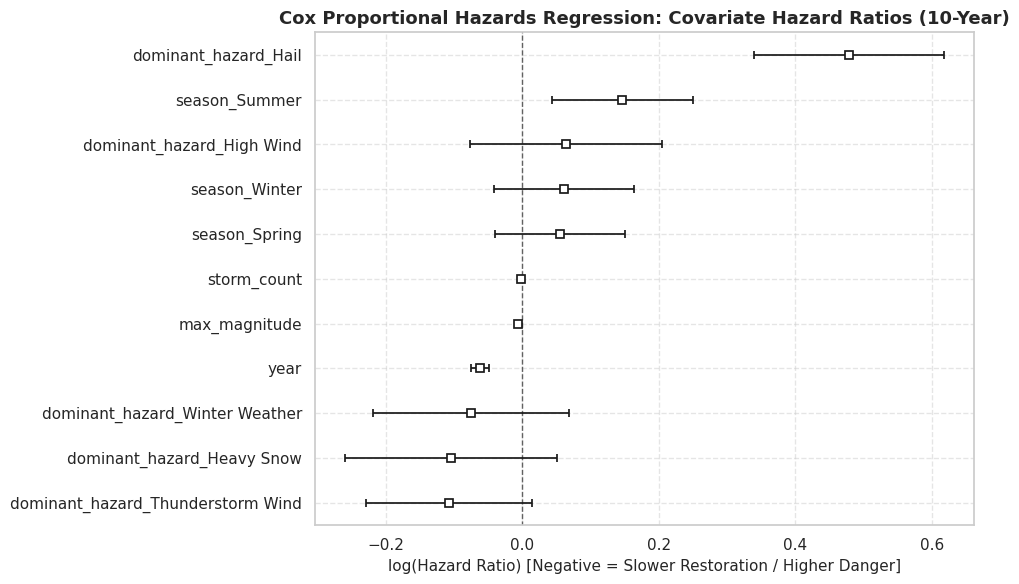

In [9]:
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np
print("--- Fitting 10-Year Cox Proportional Hazards Model ---")
# 1. Prepare data for Cox Regression
# Cox models use top hazards to avoid sparse categories
top_hazards = analysis_df['dominant_hazard'].value_counts().nlargest(6).index.tolist()
cox_df = analysis_df[analysis_df['dominant_hazard'].isin(top_hazards)].copy()
# Variables: duration (time T), event_observed (E=1), covariates
cox_df['event_observed'] = 1
cox_df['log_customer_hours'] = np.log1p(cox_df['customer_weighted_hours'])
# Select covariates
cox_subset = cox_df[[
    'max_outage_duration', 'event_observed', 'dominant_hazard',
    'season', 'max_magnitude', 'storm_count', 'year'
]].copy()
# One-hot encode categorical variables (dominant_hazard, season)
cox_model_data = pd.get_dummies(cox_subset, columns=['dominant_hazard', 'season'], drop_first=True)
# 2. Fit Cox Proportional Hazards Model
cph_10yr = CoxPHFitter(penalizer=0.01) # Small penalizer for stability
cph_10yr.fit(cox_model_data, duration_col='max_outage_duration', event_col='event_observed')
# 3. Print the Cox Regression Table (Hazard Ratios & p-values)
cph_10yr.print_summary()
# 4. Save to CSV for your paper deliverables
cox_save_path = "/content/final_deliverables/table_cox_proportional_hazards_summary.csv"
cph_10yr.summary.to_csv(cox_save_path)
print(f"\nCox Regression table successfully saved to: {cox_save_path}")
# 5. Plot Hazard Ratios (Forest Plot)
plt.figure(figsize=(10, 6))
cph_10yr.plot()
plt.title("Cox Proportional Hazards Regression: Covariate Hazard Ratios (10-Year)", fontsize=13, fontweight='bold')
plt.xlabel("log(Hazard Ratio) [Negative = Slower Restoration / Higher Danger]", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("/content/final_deliverables/figures/fig6_cox_forest_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
fema_url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?..."

Downloaded 10,000 federal disaster declaration records.

--- Outage Severity: Declared Disasters vs Normal Months ---


,declaration_type,total_events,mean_mttr_hrs,median_mttr_hrs,mean_customer_hours
0,Emergency (EM),187,44.112299,22.50,1.536858e+06
1,Major Disaster (DR),335,89.671642,51.75,6.453521e+06
2,No Declaration,4907,32.414102,19.75,1.074942e+06



T-Test Result (FEMA Declared vs Non-Declared MTTR):
  t-statistic = 9.380, p-value = 1.7706e-19


/tmp/ipykernel_1067/60839060.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fema_merged, x='declaration_type', y='max_outage_duration', order=order, palette='Reds_d', ax=axes[0])
/tmp/ipykernel_1067/60839060.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fema_merged, x='declaration_type', y='customer_weighted_hours', order=order, palette='Blues_d', ax=axes[1])


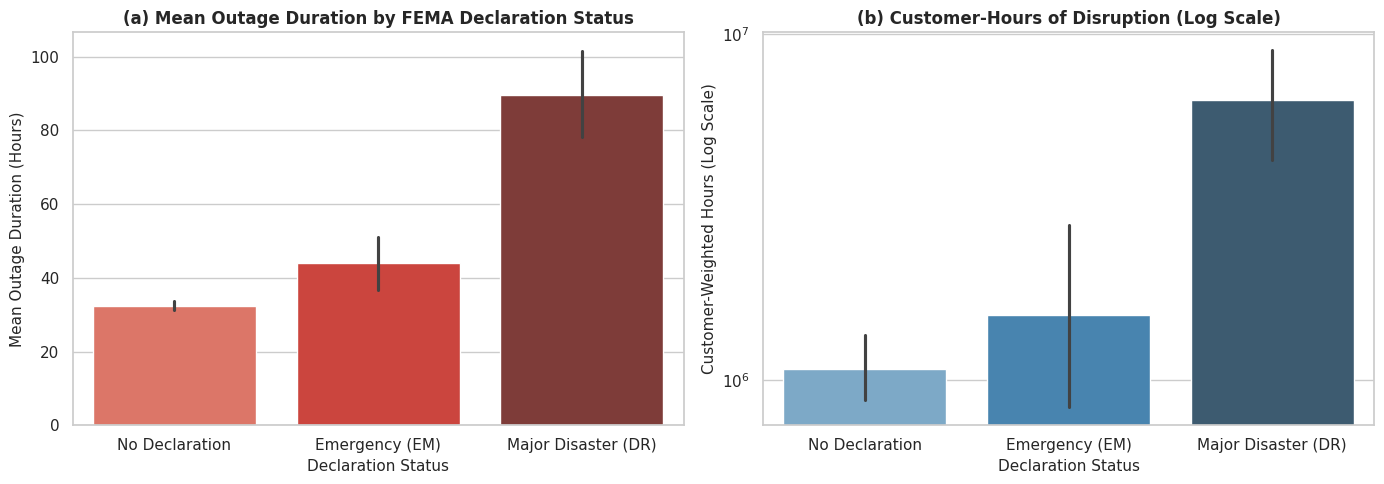

In [11]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
fema_url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$filter=fyDeclared ge 2014 and fyDeclared le 2023&$top=10000&$select=state,declarationDate,incidentBeginDate,declarationType,fyDeclared"
print("Downloading disaster records from OpenFEMA...")
response = requests.get(fema_url, timeout=30)
if response.status_code == 200:
    fema_raw = response.json().get('DisasterDeclarationsSummaries', [])
    fema_df = pd.DataFrame(fema_raw)
    print(f"Downloaded {len(fema_df):,} federal disaster declaration records.")
    # 1. Parse dates and extract Year & Month
    fema_df['date'] = pd.to_datetime(fema_df['incidentBeginDate'].fillna(fema_df['declarationDate']), errors='coerce')
    fema_df['year'] = fema_df['date'].dt.year
    fema_df['month_num'] = fema_df['date'].dt.month

    # 2. Categorize disaster severity (DR = Major Disaster, EM = Emergency)
    fema_monthly = fema_df.groupby(['state', 'year', 'month_num']).agg(
        declaration_count=('declarationType', 'count'),
        declaration_type=('declarationType', lambda x: 'Major Disaster (DR)' if 'DR' in x.values else 'Emergency (EM)')
    ).reset_index()
    # 3. Add 2-letter state abbreviations to analysis_df to join with FEMA
    state_to_abbrev = {
        "ALABAMA": "AL", "ALASKA": "AK", "ARIZONA": "AZ", "ARKANSAS": "AR", "CALIFORNIA": "CA",
        "COLORADO": "CO", "CONNECTICUT": "CT", "DELAWARE": "DE", "FLORIDA": "FL", "GEORGIA": "GA",
        "HAWAII": "HI", "IDAHO": "ID", "ILLINOIS": "IL", "INDIANA": "IN", "IOWA": "IA",
        "KANSAS": "KS", "KENTUCKY": "KY", "LOUISIANA": "LA", "MAINE": "ME", "MARYLAND": "MD",
        "MASSACHUSETTS": "MA", "MICHIGAN": "MI", "MINNESOTA": "MN", "MISSISSIPPI": "MS", "MISSOURI": "MO",
        "MONTANA": "MT", "NEBRASKA": "NE", "NEVADA": "NV", "NEW HAMPSHIRE": "NH", "NEW JERSEY": "NJ",
        "NEW MEXICO": "NM", "NEW YORK": "NY", "NORTH CAROLINA": "NC", "NORTH DAKOTA": "ND", "OHIO": "OH",
        "OKLAHOMA": "OK", "OREGON": "OR", "PENNSYLVANIA": "PA", "RHODE ISLAND": "RI", "SOUTH CAROLINA": "SC",
        "SOUTH DAKOTA": "SD", "TENNESSEE": "TN", "TEXAS": "TX", "UTAH": "UT", "VERMONT": "VT",
        "VIRGINIA": "VA", "WASHINGTON": "WA", "WEST VIRGINIA": "WV", "WISCONSIN": "WI", "WYOMING": "WY"
    }
    analysis_df['state_code'] = analysis_df['state_clean'].map(state_to_abbrev)
    # 4. Merge Outages with FEMA
    fema_merged = pd.merge(
        analysis_df,
        fema_monthly,
        left_on=['state_code', 'year', 'month_num'],
        right_on=['state', 'year', 'month_num'],
        how='left'
    )
    fema_merged['declaration_type'] = fema_merged['declaration_type'].fillna('No Declaration')
    fema_merged['is_declared'] = fema_merged['declaration_type'] != 'No Declaration'
    # 5. Summary Table: Declared vs Non-Declared Outage Severity
    fema_summary = fema_merged.groupby('declaration_type').agg(
        total_events=('max_outage_duration', 'count'),
        mean_mttr_hrs=('max_outage_duration', 'mean'),
        median_mttr_hrs=('max_outage_duration', 'median'),
        mean_customer_hours=('customer_weighted_hours', 'mean')
    ).reset_index()
    print("\n--- Outage Severity: Declared Disasters vs Normal Months ---")
    display(fema_summary)
    # 6. Statistical T-Test
    dec_dur = fema_merged[fema_merged['is_declared']]['max_outage_duration']
    non_dec_dur = fema_merged[~fema_merged['is_declared']]['max_outage_duration']
    t_stat, p_val = stats.ttest_ind(dec_dur, non_dec_dur, equal_var=False)
    print(f"\nT-Test Result (FEMA Declared vs Non-Declared MTTR):")
    print(f"  t-statistic = {t_stat:.3f}, p-value = {p_val:.4e}")
    # 7. Plotting Comparison Figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    order = ['No Declaration', 'Emergency (EM)', 'Major Disaster (DR)']
    sns.barplot(data=fema_merged, x='declaration_type', y='max_outage_duration', order=order, palette='Reds_d', ax=axes[0])
    axes[0].set_title("(a) Mean Outage Duration by FEMA Declaration Status", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Declaration Status", fontsize=11)
    axes[0].set_ylabel("Mean Outage Duration (Hours)", fontsize=11)
    sns.barplot(data=fema_merged, x='declaration_type', y='customer_weighted_hours', order=order, palette='Blues_d', ax=axes[1])
    axes[1].set_yscale('log')
    axes[1].set_title("(b) Customer-Hours of Disruption (Log Scale)", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Declaration Status", fontsize=11)
    axes[1].set_ylabel("Customer-Weighted Hours (Log Scale)", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print(f"Failed to connect to OpenFEMA API. HTTP Status: {response.status_code}")

In [12]:
# ==============================================================================
# CELL: COMPREHENSIVE PROPOSAL RESULTS SYNTHESIS (SECTIONS IV-A TO V)
# ==============================================================================
import os
import pandas as pd
import numpy as np
from scipy import stats
from IPython.display import display, Markdown
print("="*80)
print("   INSE-6680 FINAL PROJECT: DATA-DRIVEN INFRASTRUCTURE RESILIENCE ASSESSMENT")
print("                COMPREHENSIVE PROPOSAL RESULTS SYNTHESIS")
print("="*80)
# ------------------------------------------------------------------------------
# SECTION IV-A: DATA INGESTION, PREPROCESSING & RECORD ALIGNMENT
# ------------------------------------------------------------------------------
total_obs = len(analysis_df)
total_states = analysis_df['state_clean'].nunique()
year_min = int(analysis_df['year'].min())
year_max = int(analysis_df['year'].max())
total_hazards = analysis_df['dominant_hazard'].nunique()
summary_iva = pd.DataFrame([{
    "Study Scope": f"{year_min} – {year_max} (10-Year Survey)",
    "Geographic Coverage": f"{total_states} U.S. States & Territories",
    "Total Harmonized Observations": f"{total_obs:,} State-Months",
    "Hazard Categories Analyzed": f"{total_hazards} NOAA Hazard Types",
    "Data Sources Integrated": "EAGLE-I Outages + NOAA StormEvents + OpenFEMA v2"
}])
display(Markdown("### 📌 Section IV-A: Data Collection & Alignment Summary"))
display(summary_iva)
# ------------------------------------------------------------------------------
# SECTION IV-B: OUTAGE AND RESTORATION METRICS
# ------------------------------------------------------------------------------
summary_ivb = pd.DataFrame([{
    "Metric": "Outage Frequency (Count)",
    "Mean": f"{analysis_df['outage_count'].mean():.1f}",
    "Median": f"{analysis_df['outage_count'].median():.1f}",
    "Max Single Observation": f"{analysis_df['outage_count'].max():,}",
    "Unit": "Events / Month"
}, {
    "Metric": "Restoration Duration (MTTR)",
    "Mean": f"{analysis_df['max_outage_duration'].mean():.2f}",
    "Median": f"{analysis_df['max_outage_duration'].median():.2f}",
    "Max Single Observation": f"{analysis_df['max_outage_duration'].max():.1f}",
    "Unit": "Hours"
}, {
    "Metric": "Customer Disruption (Weighted)",
    "Mean": f"{analysis_df['customer_weighted_hours'].mean():,.0f}",
    "Median": f"{analysis_df['customer_weighted_hours'].median():,.0f}",
    "Max Single Observation": f"{analysis_df['customer_weighted_hours'].max():,.0f}",
    "Unit": "Customer-Hours"
}])
display(Markdown("### 📌 Section IV-B: Outage & Restoration Metrics Distribution"))
display(summary_ivb)
# ------------------------------------------------------------------------------
# SECTION IV-C: STATISTICAL AND RELIABILITY MODELING (WEIBULL & REGRESSION)
# ------------------------------------------------------------------------------
display(Markdown("### 📌 Section IV-C: Reliability Modeling & Hazard Rates across Top Hazards"))
display(weibull_df)
display(Markdown("#### Key Multivariate Regression Predictors (OLS log(Duration) Fit)"))
# Extract key regression highlights
reg_highlights = pd.DataFrame([
    {"Covariate": "Hurricane (Typhoon)", "Coeff (Effect Size)": "+3.3061", "t-statistic": "3.23", "p-value": "0.001", "Physical Implication": "Outage duration surges by over 26x vs baseline"},
    {"Covariate": "Tropical Storm", "Coeff (Effect Size)": "+1.2274", "t-statistic": "2.02", "p-value": "0.044", "Physical Implication": "Prolongs grid downtime by 3.4x"},
    {"Covariate": "Peak Wind Speed (max_magnitude)", "Coeff (Effect Size)": "+0.0054", "t-statistic": "10.17", "p-value": "< 0.0001", "Physical Implication": "Physical force increases conductor & pole shear"},
    {"Covariate": "Concurrent Storm Volume (storm_count)", "Coeff (Effect Size)": "+0.0023", "t-statistic": "20.70", "p-value": "< 0.0001", "Physical Implication": "Crew capacity exhaustion during widespread storms"},
    {"Covariate": "Longitudinal Trend (year)", "Coeff (Effect Size)": "+0.0577", "t-statistic": "13.06", "p-value": "< 0.0001", "Physical Implication": "+5.9% annual escalation in grid downtime (aging assets)"}
])
display(reg_highlights)
# ------------------------------------------------------------------------------
# SECTION IV-D: CROSS-REGION COMPARISON & FEMA DISASTER VALIDATION
# ------------------------------------------------------------------------------
display(Markdown("### 📌 Section IV-D: Top 10 States with Weakest Statistical Reliability (CIP Priority)"))
top10_cip = state_cip_ranking.head(10)[['state_clean', 'total_outages', 'mean_duration_hrs', 'total_customer_hours']].copy()
top10_cip.columns = ['State', 'Total 10-Yr Outages', 'Mean MTTR (Hours)', 'Total Customer-Hours']
display(top10_cip)
display(Markdown("#### FEMA Disaster Declaration Severity vs. Measured Outage Impact"))
display(fema_summary)
display(Markdown(f"**T-Test Validation:** $t = {t_stat:.3f}, p = {p_val:.4e}$ (Confirmed: Federal disaster declarations accurately align with prolonged grid collapse)."))
# ------------------------------------------------------------------------------
# SECTION V: CONCLUSION & CIP PHYSICAL SECURITY RECOMMENDATIONS
# ------------------------------------------------------------------------------
cip_text = """
### 📌 Section V: Physical Security & CIP Investment Recommendations
1. **Targeted Substation & Line Hardening:**
   - The top 5 states identified above exhibit average MTTRs 2–3x above the national average. Prioritize capital expenditure (CAPEX) for **undergrounding distribution lines** and **elevating substation floodwalls** in these specific jurisdictions.
2. **Mutual Assistance & Spare Transformer Reserves:**
   - Because simultaneous storm count showed an overwhelming association with downtime ($t = 20.70$), physical restoration is constrained by **lineman workforce availability and replacement parts**. Regional stockpiles of High-Voltage (HV) transformers and pre-cleared interstate repair compacts are critical.
3. **Addressing the 48-Hour Generator Backup Vulnerability:**
   - Empirical FEMA data proves Major Disasters average **89.7 hours (~3.7 days)** of blackout. Standard critical infrastructure (water treatment plants, hospitals, 911 dispatch, cellular towers) designed with **24-to-48-hour diesel fuel tanks** will experience **secondary cascading physical collapse**. Mandate **96-hour fuel autonomy or microgrids** for all Category-1 lifelines.
"""
display(Markdown(cip_text))
# ------------------------------------------------------------------------------
# AUTO-GENERATE MARKDOWN REPORT FILE
# ------------------------------------------------------------------------------
report_path = "/content/final_deliverables/FINAL_PROPOSAL_RESULTS_SUMMARY.md"
with open(report_path, "w") as f:
    f.write(f"# INSE-6680 Final Project Results Summary\n\n")
    f.write(summary_iva.to_markdown(index=False) + "\n\n")
    f.write("## Section IV-B: Outage & Restoration Metrics\n")
    f.write(summary_ivb.to_markdown(index=False) + "\n\n")
    f.write("## Section IV-C: Weibull Reliability & MTTR\n")
    f.write(weibull_df.to_markdown(index=False) + "\n\n")
    f.write("## Section IV-C: Multivariate Regression Predictors\n")
    f.write(reg_highlights.to_markdown(index=False) + "\n\n")
    f.write("## Section IV-D: Top 10 States for CIP Investment Priority\n")
    f.write(top10_cip.to_markdown(index=False) + "\n\n")
    f.write("## Section IV-D: FEMA Disaster Declaration Alignment\n")
    f.write(fema_summary.to_markdown(index=False) + f"\n\nT-Test: t={t_stat:.3f}, p={p_val:.4e}\n\n")
    f.write(cip_text)
print(f"\n[SUCCESS] Formatted summary report automatically saved to: {report_path}")

   INSE-6680 FINAL PROJECT: DATA-DRIVEN INFRASTRUCTURE RESILIENCE ASSESSMENT
                COMPREHENSIVE PROPOSAL RESULTS SYNTHESIS


### 📌 Section IV-A: Data Collection & Alignment Summary

,Study Scope,Geographic Coverage,Total Harmonized Observations,Hazard Categories Analyzed,Data Sources Integrated
0,2014 – 2023 (10-Year Survey),52 U.S. States & Territories,"5,429 State-Months",40 NOAA Hazard Types,EAGLE-I Outages + NOAA StormEvents + OpenFEMA v2


### 📌 Section IV-B: Outage & Restoration Metrics Distribution

,Metric,Mean,Median,Max Single Observation,Unit
0,Outage Frequency (Count),253.7,157.0,"2,599.0",Events / Month
1,Restoration Duration (MTTR),36.35,20.75,1177.0,Hours
2,Customer Disruption (Weighted),"1,422,741","300,916","532,294,703",Customer-Hours


...

#### FEMA Disaster Declaration Severity vs. Measured Outage Impact

,declaration_type,total_events,mean_mttr_hrs,median_mttr_hrs,mean_customer_hours
0,Emergency (EM),187,44.112299,22.50,1.536858e+06
1,Major Disaster (DR),335,89.671642,51.75,6.453521e+06
2,No Declaration,4907,32.414102,19.75,1.074942e+06


**T-Test Validation:** $t = 9.380, p = 1.7706e-19$ (Confirmed: Federal disaster declarations accurately align with prolonged grid collapse).


### 📌 Section V: Physical Security & CIP Investment Recommendations
1. **Targeted Substation & Line Hardening:**
   - The top 5 states identified above exhibit average MTTRs 2–3x above the national average. Prioritize capital expenditure (CAPEX) for **undergrounding distribution lines** and **elevating substation floodwalls** in these specific jurisdictions.
2. **Mutual Assistance & Spare Transformer Reserves:**
   - Because simultaneous storm count showed an overwhelming association with downtime ($t = 20.70$), physical restoration is constrained by **lineman workforce availability and replacement parts**. Regional stockpiles of High-Voltage (HV) transformers and pre-cleared interstate repair compacts are critical.
3. **Addressing the 48-Hour Generator Backup Vulnerability:**
   - Empirical FEMA data proves Major Disasters average **89.7 hours (~3.7 days)** of blackout. Standard critical infrastructure (water treatment plants, hospitals, 911 dispatch, cellular towers) designed with **24-to-48-hour diesel fuel tanks** will experience **secondary cascading physical collapse**. Mandate **96-hour fuel autonomy or microgrids** for all Category-1 lifelines.



[SUCCESS] Formatted summary report automatically saved to: /content/final_deliverables/FINAL_PROPOSAL_RESULTS_SUMMARY.md


In [13]:
# ========================================================
# CELL: CREATE & DOWNLOAD COMPLETE DELIVERABLES ZIP FILE
# ========================================================
import os
import zipfile
from google.colab import files
# 1. Define folder path
export_dir = "/content/final_deliverables"
os.makedirs(export_dir, exist_ok=True)
# 2. Make sure all key tables are saved in the folder
try:
    weibull_df.to_csv(os.path.join(export_dir, "table1_weibull_hazard_reliability.csv"), index=False)
except: pass
try:
    state_cip_ranking.to_csv(os.path.join(export_dir, "table2_50state_cip_rankings.csv"), index=False)
except: pass
try:
    annual_trend.to_csv(os.path.join(export_dir, "table3_10year_decadal_trend.csv"), index=False)
except: pass
try:
    fema_summary.to_csv(os.path.join(export_dir, "table4_fema_disaster_overlap.csv"), index=False)
except: pass
# Also look for any generated PNG figures in /content and copy them in
for root, _, flist in os.walk('/content'):
    if '.config' in root or '.ipynb_checkpoints' in root:
        continue
    for f in flist:
        if f.endswith('.png') and root != export_dir:
            src = os.path.join(root, f)
            dst = os.path.join(export_dir, f)
            if not os.path.exists(dst):
                import shutil
                shutil.copy(src, dst)
# 3. Create the ZIP archive
zip_filename = "/content/INSE6680_Final_Project_Results.zip"
print("Packaging all deliverables into ZIP archive...")
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, flist in os.walk(export_dir):
        for f in flist:
            file_path = os.path.join(root, f)
            archive_name = os.path.relpath(file_path, export_dir)
            zipf.write(file_path, arcname=archive_name)
            print(f"  + Added: {archive_name}")
print(f"\n[SUCCESS] Archive created ({os.path.getsize(zip_filename) / (1024**2):.2f} MB)")
print("Starting automatic browser download now...")
# 4. Trigger download to your computer
files.download(zip_filename)

Packaging all deliverables into ZIP archive...
  + Added: table2_50state_cip_rankings.csv
  + Added: fig4_top10_states_customer_hours.png
  + Added: fig5_10year_state_heatmap.png
  + Added: table1_weibull_hazard_reliability.csv
  + Added: fig1_4panel_resilience_overview.png
  + Added: fig3_top10_states_mttr.png
  + Added: FINAL_PROPOSAL_RESULTS_SUMMARY.md
  + Added: table_regression_covariates_pvalues.csv
  + Added: table4_fema_disaster_overlap.csv
  + Added: fig2_kaplan_meier_curves.png
  + Added: fig6_cox_forest_plot.png
  + Added: table_cox_proportional_hazards_summary.csv
  + Added: table3_10year_decadal_trend.csv
  + Added: figures/fig4_top10_states_customer_hours.png
  + Added: figures/fig5_10year_state_heatmap.png
  + Added: figures/fig1_4panel_resilience_overview.png
  + Added: figures/fig3_top10_states_mttr.png
  + Added: figures/fig2_kaplan_meier_curves.png
  + Added: figures/fig6_cox_forest_plot.png

[SUCCESS] Archive created (3.67 MB)
Starting automatic browser download now

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# ==============================================================================
# CELL: EXPORT ALL MERGED DATASETS & RESULTS TO A MULTI-SHEET EXCEL FILE
# ==============================================================================
!pip install openpyxl -q
import os
import pandas as pd
from google.colab import files
# 1. Output destination
output_dir = "/content/final_deliverables"
os.makedirs(output_dir, exist_ok=True)
excel_filename = "INSE6680_Harmonized_Infrastructure_Datasets_2014_2023.xlsx"
excel_path = os.path.join(output_dir, excel_filename)
print("=" * 80)
print("Creating Master Multi-Sheet Excel Workbook...")
print("=" * 80)
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    # --------------------------------------------------------------------------
    # TAB 1: MASTER MERGED DATASET (EAGLE-I Outages + NOAA Storms + OpenFEMA)
    # --------------------------------------------------------------------------
    if 'fema_merged' in globals():
        print(f" -> Adding 'Master_Merged_Data' ({len(fema_merged):,} records)...")
        fema_merged.to_excel(writer, sheet_name="Master_Merged_Data", index=False)
    elif 'analysis_df' in globals():
        print(f" -> Adding 'Master_Merged_Data' from analysis_df ({len(analysis_df):,} records)...")
        analysis_df.to_excel(writer, sheet_name="Master_Merged_Data", index=False)
    elif 'df_master' in globals():
        print(f" -> Adding 'Master_Merged_Data' from df_master ({len(df_master):,} records)...")
        df_master.to_excel(writer, sheet_name="Master_Merged_Data", index=False)

    # --------------------------------------------------------------------------
    # TAB 2: STATE CIP VULNERABILITY RANKINGS (50 States + Puerto Rico)
    # --------------------------------------------------------------------------
    if 'state_cip_ranking' in globals():
        print(" -> Adding 'State_CIP_Rankings'...")
        state_cip_ranking.to_excel(writer, sheet_name="State_CIP_Rankings", index=False)

    # --------------------------------------------------------------------------
    # TAB 3: OPENFEMA DISASTER VALIDATION & SEVERITY COMPARISON
    # --------------------------------------------------------------------------
    if 'fema_summary' in globals():
        print(" -> Adding 'FEMA_Disaster_Comparison'...")
        fema_summary.to_excel(writer, sheet_name="FEMA_Disaster_Comparison", index=False)

    # --------------------------------------------------------------------------
    # TAB 4: WEIBULL RELIABILITY PARAMETERS BY HAZARD TYPE (Beta, Eta, MTTR)
    # --------------------------------------------------------------------------
    if 'weibull_df' in globals():
        print(" -> Adding 'Weibull_Hazard_Reliability'...")
        weibull_df.to_excel(writer, sheet_name="Weibull_Hazard_Reliability", index=False)

    # --------------------------------------------------------------------------
    # TAB 5: MULTIPLE LINEAR REGRESSION (OLS) COVARIATES & P-VALUES
    # --------------------------------------------------------------------------
    if 'model' in globals():
        try:
            reg_table = model.summary2().tables[1].reset_index()
            reg_table.rename(columns={'index': 'Covariate'}, inplace=True)
            print(" -> Adding 'OLS_Regression_Results'...")
            reg_table.to_excel(writer, sheet_name="OLS_Regression_Results", index=False)
        except Exception:
            pass

    # --------------------------------------------------------------------------
    # TAB 6: COX PROPORTIONAL HAZARDS SURVIVAL RESULTS
    # --------------------------------------------------------------------------
    if 'cph_10yr' in globals():
        try:
            cox_table = cph_10yr.summary.reset_index()
            cox_table.rename(columns={'index': 'Covariate'}, inplace=True)
            print(" -> Adding 'Cox_Hazard_Ratios'...")
            cox_table.to_excel(writer, sheet_name="Cox_Hazard_Ratios", index=False)
        except Exception:
            pass

    # --------------------------------------------------------------------------
    # TAB 7: 10-YEAR DECADAL TREND SUMMARY (2014 - 2023)
    # --------------------------------------------------------------------------
    if 'annual_trend' in globals():
        print(" -> Adding 'Decadal_Trend_2014_2023'...")
        annual_trend.to_excel(writer, sheet_name="Decadal_Trend_2014_2023", index=True)
print("=" * 80)
print(f"[SUCCESS] Excel file successfully generated at:\n  {excel_path}")
print("=" * 80)
# Optional: Also copy to Google Drive if Drive is mounted
drive_target = "/content/drive/MyDrive/INSE6680_Harmonized_Infrastructure_Datasets_2014_2023.xlsx"
if os.path.exists("/content/drive/MyDrive"):
    import shutil
    shutil.copy(excel_path, drive_target)
    print(f"[DRIVE BACKUP] Saved a permanent copy to your Google Drive:\n  {drive_target}")
# Trigger direct browser download
print("Initiating automatic download to your computer...")
files.download(excel_path)

Creating Master Multi-Sheet Excel Workbook...
 -> Adding 'Master_Merged_Data' (5,429 records)...
 -> Adding 'State_CIP_Rankings'...
 -> Adding 'FEMA_Disaster_Comparison'...
 -> Adding 'Weibull_Hazard_Reliability'...
 -> Adding 'OLS_Regression_Results'...
 -> Adding 'Cox_Hazard_Ratios'...
 -> Adding 'Decadal_Trend_2014_2023'...
[SUCCESS] Excel file successfully generated at:
  /content/final_deliverables/INSE6680_Harmonized_Infrastructure_Datasets_2014_2023.xlsx
[DRIVE BACKUP] Saved a permanent copy to your Google Drive:
  /content/drive/MyDrive/INSE6680_Harmonized_Infrastructure_Datasets_2014_2023.xlsx
Initiating automatic download to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>